# Household Behavior over the Life Cycle Exam 2026

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from scipy.optimize import minimize, minimize_scalar, root_scalar
import matplotlib.pyplot as plt

# Labor model initialization

In [2]:
# load local model file and initialize model class
from LaborCohortModel import LaborCohortModelClass
model = LaborCohortModelClass()

In [3]:
%time model.solve()
%time model.simulate()

CPU times: user 8.28 s, sys: 212 ms, total: 8.5 s
Wall time: 3.46 s
CPU times: user 6.66 s, sys: 64.7 ms, total: 6.72 s
Wall time: 6.71 s


### Q2: Simulate two versions of the model as $\tau=0$ and $\tau=0.3$. 

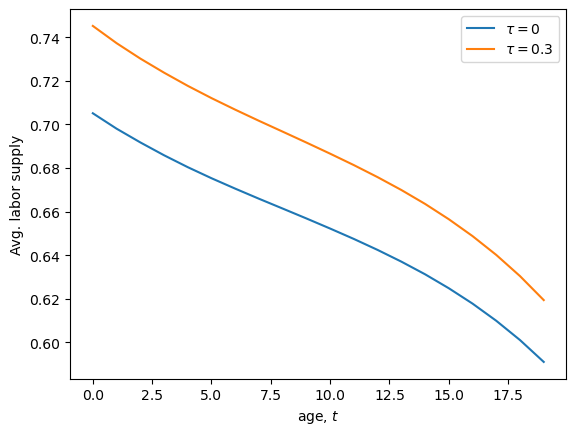

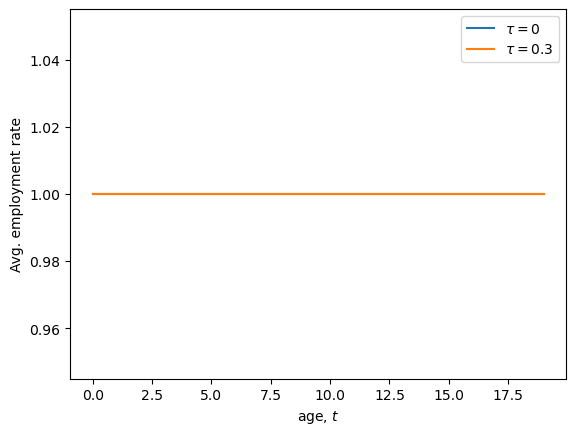

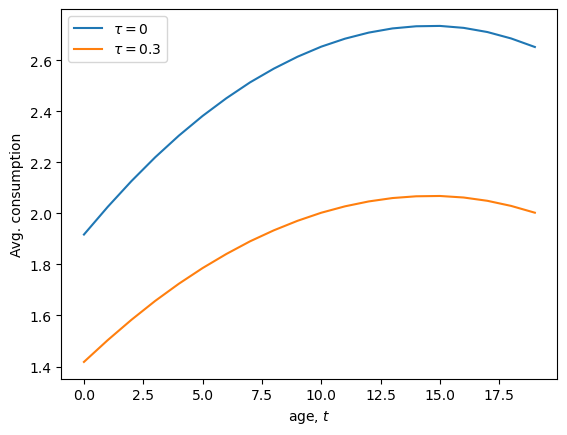

In [ ]:
# build the two versions (tax is already a parameter)
model_notax = LaborCohortModelClass(par={'tau':0.0})
model_tax   = LaborCohortModelClass(par={'tau':0.3})
for m in (model_notax, model_tax):
    m.solve()
    m.simulate()

reduce = {'h':   lambda sim: np.nanmean(sim.h, axis=0),
          'emp': lambda sim: np.mean(sim.h > 1e-6, axis=0),
          'c':   lambda sim: np.nanmean(sim.c, axis=0)}
labels = {'h':'labor supply', 'emp':'employment rate', 'c':'consumption'}

for val in ('h','emp','c'):
    var1 = reduce[val](model_notax.sim)
    var2 = reduce[val](model_tax.sim)
    fig, ax = plt.subplots()
    ax.plot(var1, label=r'$\tau=0$')
    ax.plot(var2, label=r'$\tau=0.3$')
    ax.set(ylabel=f'Avg. {labels[val]}', xlabel='age, $t$')
    ax.legend()

### Q3: Government


In [7]:
model = LaborCohortModelClass()
model.solve()
model.simulate()

# Summing over all periods and individuals
G3 = model.sim.G.sum()
print(f'G3 = {G3:.3f}')

G3 = 808284.827


[Text(0.5, 0, 'tax rate, $\\tau$'),
 Text(0, 0.5, 'government budget, $G(\\theta)$')]

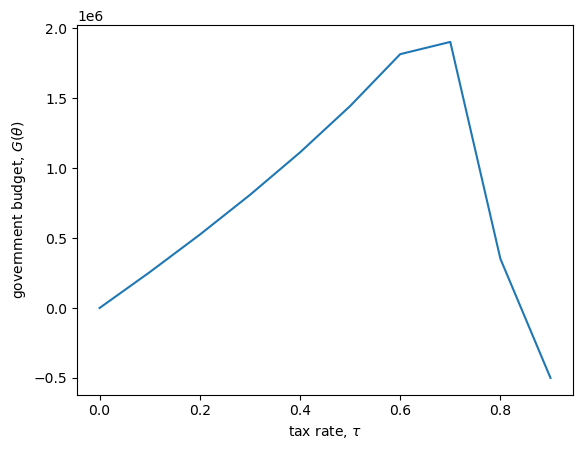

In [9]:
taus = np.arange(0.0,1.0,0.1)   
G_tau = np.zeros(taus.size)

for j,tau in enumerate(taus):
    m = LaborCohortModelClass(par={'tau':tau})
    m.solve()
    m.simulate()
    G_tau[j] = m.sim.G.sum()        

fig,ax = plt.subplots()
ax.plot(taus,G_tau)
ax.set(xlabel=r'tax rate, $\tau$', ylabel=r'government budget, $G(\theta)$')

### Q4:New unemployment benefit


In [11]:
# baseline = Q3 model: pi_1 = 0 collapses eq (7) back to pi_t = pi_0, tau = 0.3 by default
model_base = LaborCohortModelClass(name='base')
model_base.solve()
model_base.simulate()

# reform = old-age subsidy: pi_1 = 0.6
model_reform = LaborCohortModelClass(name='reform', par={'pi_1':0.6})
model_reform.solve()
model_reform.simulate()

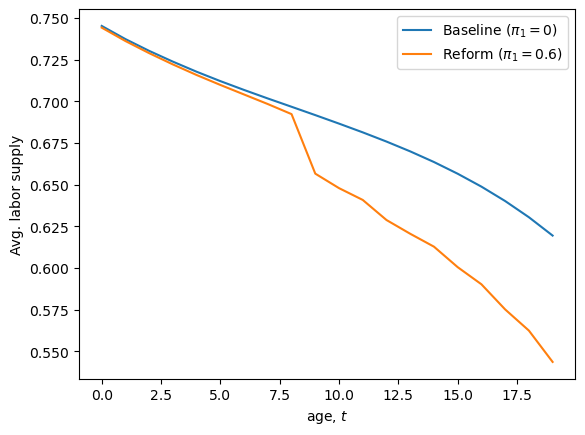

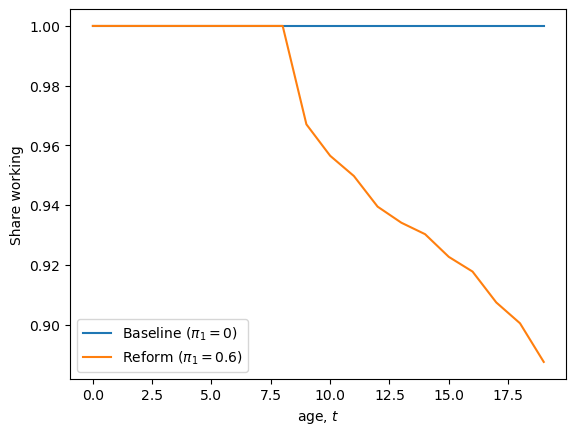

In [12]:
age = np.arange(model_base.par.simT)

# average labor supply over age
fig,ax = plt.subplots()
ax.plot(age, np.nanmean(model_base.sim.h,   axis=0), label='Baseline ($\\pi_1=0$)')
ax.plot(age, np.nanmean(model_reform.sim.h, axis=0), label='Reform ($\\pi_1=0.6$)')
ax.set_xlabel('age, $t$'); ax.set_ylabel('Avg. labor supply'); ax.legend()

# share working over age
fig,ax = plt.subplots()
ax.plot(age, np.nanmean(model_base.sim.h   > 1e-6, axis=0), label='Baseline ($\\pi_1=0$)')
ax.plot(age, np.nanmean(model_reform.sim.h > 1e-6, axis=0), label='Reform ($\\pi_1=0.6$)')
ax.set_xlabel('age, $t$'); ax.set_ylabel('Share working'); ax.legend()